
# Valuation Gap Difference Model – Policy Transmission Analysis

This notebook implements a **clean, coherent pipeline**:

1. Data Preparation  
2. Feature Engineering  
3. Exploratory Analysis  
4. OLS (Mean Model)  
5. Quantile Regression (Distributional Model)  
6. Key Insights  

Focus: Understanding how **ΔRepo affects valuation gap dynamics across regimes and distribution tails**.


In [1]:

import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns


## Load Data

In [2]:

# Replace with your actual file
df = pd.read_csv("final_model_dataset.csv")

df.head()


,city,quarter,rent,hpi,rent_growth,hpi_growth,valuation_gap,repo_rate,hpi_lag,rent_lag,repo_growth,repo_lag
0,bangalore,Q1 2015,104.4500,61.806841,0.043538,0.237475,-0.193937,7.782887,NaN,NaN,NaN,NaN
1,bangalore,Q1 2016,114.6000,71.406332,0.092739,0.144372,-0.051633,7.657853,0.237475,0.043538,-0.016196,NaN
2,bangalore,Q1 2017,121.9875,75.582470,0.062471,0.056838,0.005633,6.962920,0.144372,0.092739,-0.095133,-0.016196
3,bangalore,Q1 2018,145.2250,77.997789,0.174366,0.031456,0.142910,7.466353,0.056838,0.062471,0.069808,-0.095133
4,bangalore,Q1 2019,144.7375,83.885498,-0.003363,0.072772,-0.076135,7.397403,0.031456,0.174366,-0.009278,0.069808


## Feature Engineering

In [3]:
df['hpi_lag'] = df.groupby('city')['hpi'].shift(1)
df['regime'] = pd.qcut(df['hpi_lag'], q=3, labels=['low', 'mid', 'high'], duplicates='drop')
display(df[['city', 'quarter', 'hpi', 'hpi_lag', 'regime']].head())
# Delta repo (policy shock)
df["delta_repo"] = df["repo_rate"].diff()

# Valuation gap (if not already present)
# df["valuation_gap"] = df["hpi_growth"] - df["rent_growth"]

# Delta valuation gap
df["delta_valuation_gap"] = df["valuation_gap"].diff()

# Regime dummies (example – adjust thresholds)
df["low_regime"] = (df["regime"] == "low").astype(int)
df["high_regime"] = (df["regime"] == "high").astype(int)

df = df.dropna()

df.head()


,city,quarter,hpi,hpi_lag,regime
0,bangalore,Q1 2015,61.806841,NaN,NaN
1,bangalore,Q1 2016,71.406332,61.806841,low
2,bangalore,Q1 2017,75.582470,71.406332,low
3,bangalore,Q1 2018,77.997789,75.582470,low
4,bangalore,Q1 2019,83.885498,77.997789,low


,city,quarter,rent,hpi,rent_growth,hpi_growth,valuation_gap,repo_rate,hpi_lag,rent_lag,repo_growth,repo_lag,regime,delta_repo,delta_valuation_gap,low_regime,high_regime
2,bangalore,Q1 2017,121.9875,75.582470,0.062471,0.056838,0.005633,6.962920,71.406332,0.092739,-0.095133,-0.016196,low,-0.694933,0.057266,1,0
3,bangalore,Q1 2018,145.2250,77.997789,0.174366,0.031456,0.142910,7.466353,75.582470,0.062471,0.069808,-0.095133,low,0.503433,0.137277,1,0
4,bangalore,Q1 2019,144.7375,83.885498,-0.003363,0.072772,-0.076135,7.397403,77.997789,0.174366,-0.009278,0.069808,low,-0.068950,-0.219044,1,0
5,bangalore,Q1 2020,154.9500,91.129073,0.068181,0.082824,-0.014643,6.727675,83.885498,-0.003363,-0.094899,-0.009278,low,-0.669728,0.061491,1,0
6,bangalore,Q1 2021,161.3125,105.782993,0.040241,0.149113,-0.108872,6.161965,91.129073,0.068181,-0.087834,-0.094899,mid,-0.565710,-0.094228,0,0


## Exploratory Analysis

In [4]:

corr = df.corr(numeric_only=True)
print(corr["delta_valuation_gap"].sort_values(ascending=False))


delta_valuation_gap    1.000000
valuation_gap          0.693906
rent_growth            0.432892
repo_growth            0.157924
delta_repo             0.153097
hpi_lag                0.133164
high_regime            0.088325
repo_rate              0.078154
low_regime            -0.060446
hpi                   -0.083319
repo_lag              -0.084948
rent                  -0.127200
rent_lag              -0.367157
hpi_growth            -0.443096
Name: delta_valuation_gap, dtype: float64


## OLS Model (Mean Effect)

In [5]:

model = smf.ols(
    "delta_valuation_gap ~ delta_repo + delta_repo:high_regime + delta_repo:low_regime",
    data=df
).fit()

print(model.summary())


                             OLS Regression Results                            
Dep. Variable:     delta_valuation_gap   R-squared:                       0.046
Model:                             OLS   Adj. R-squared:                  0.027
Method:                  Least Squares   F-statistic:                     2.353
Date:                 Sun, 03 May 2026   Prob (F-statistic):             0.0746
Time:                         12:15:36   Log-Likelihood:                 89.277
No. Observations:                  149   AIC:                            -170.6
Df Residuals:                      145   BIC:                            -158.5
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept         

## Quantile Regression

In [6]:

quantiles = [0.1, 0.5, 0.9]

for q in quantiles:
    print(f"\n===== Quantile {q} =====")
    mod = smf.quantreg(
        "delta_valuation_gap ~ delta_repo + delta_repo:high_regime + delta_repo:low_regime",
        df
    )
    res = mod.fit(q=q)
    print(res.summary())



===== Quantile 0.1 =====
                          QuantReg Regression Results                          
Dep. Variable:     delta_valuation_gap   Pseudo R-squared:              0.01939
Model:                        QuantReg   Bandwidth:                      0.1127
Method:                  Least Squares   Sparsity:                       0.6371
Date:                 Sun, 03 May 2026   No. Observations:                  149
Time:                         12:15:36   Df Residuals:                      145
                                         Df Model:                            3
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -0.1607      0.017     -9.626      0.000      -0.194      -0.128
delta_repo                 0.0574      0.022      2.634      0.009       0.014       0.100
delta_repo:high_regime     0.0135      0.038      

## Visualization

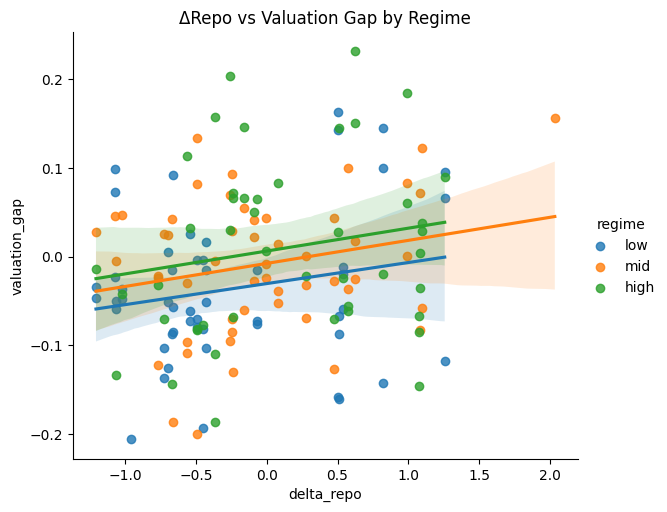

In [7]:

sns.lmplot(
    data=df,
    x="delta_repo",
    y="valuation_gap",
    hue="regime",
    height=5,
    aspect=1.2
)
plt.title("ΔRepo vs Valuation Gap by Regime")
plt.show()



## Key Findings

- OLS → No mean effect  
- Median (0.5) → No effect  
- Tails (0.1, 0.9) → Significant effects in **low regime**

### Interpretation

- Policy is **not a mean driver**
- Policy acts as a **tail regulator**
- Strong markets absorb policy
- Weak markets react strongly

---

## Final Conclusion

**Monetary policy affects valuation through distributional channels, not average outcomes.**
